In [1]:
import sys
print(sys.executable)


c:\Users\lzj\Desktop\nus\dss\5104\大作业\.venv\Scripts\python.exe


In [ ]:
import medmnist
from medmnist import INFO, Evaluator
from medmnist.dataset import PathMNIST

# 1. load dataset info
data_flag = 'pathmnist'
info = INFO[data_flag]

print("Dataset info:")
print(info)

# 2. load train / val / test datasets
train_dataset = PathMNIST(split='train', download=True)
val_dataset = PathMNIST(split='val', download=True)
test_dataset = PathMNIST(split='test', download=True)



Dataset info:
{'python_class': 'PathMNIST', 'description': 'The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC-HE-100K into training and validation set with a ratio of 9:1. The CRC-VAL-HE-7K is treated as the test set.', 'url': 'https://zenodo.org/records/10519652/files/pathmnist.npz?download=1', 'MD5': 'a8b06965200029087d5bd730944a56c1', 'url_64': 'https://zenodo.org/records/10519652/files/pathmnist_64.npz?download=1', 'MD5_64': '55aa9c1e0525abe5a6b9d8343a507616', 'url_128': 'https://zenodo.org/records/10519652/files/pathmnist_128.npz?download=1

In [ ]:
# 3. load model and set up training
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
# 4. define data transformations

# ImageNet normalization 
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# train: no augmentation
train_transform_basic = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# train: with augmentation
train_transform_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), #randomly flip the image horizontally with a probability of 0.5
    transforms.RandomRotation(10), #randomly rotate the image by a degree selected uniformly from the range (-10, 10)
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1), #randomly change the brightness, contrast and saturation of the image with a factor of 0.1
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# val / test
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

In [ ]:
# 5. apply transformations and load datasets
from medmnist.dataset import PathMNIST

train_dataset_basic = PathMNIST(split='train', transform=train_transform_basic, download=True)
train_dataset_aug = PathMNIST(split='train', transform=train_transform_aug, download=True)
val_dataset = PathMNIST(split='val', transform=test_transform, download=True)
test_dataset = PathMNIST(split='test', transform=test_transform, download=True)

print("Train (basic):", len(train_dataset_basic))
print("Train (aug):", len(train_dataset_aug))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Using downloaded and verified file: C:\Users\lzj\.medmnist\pathmnist.npz
Using downloaded and verified file: C:\Users\lzj\.medmnist\pathmnist.npz
Using downloaded and verified file: C:\Users\lzj\.medmnist\pathmnist.npz
Using downloaded and verified file: C:\Users\lzj\.medmnist\pathmnist.npz
Train (basic): 89996
Train (aug): 89996
Val: 10004
Test: 7180


In [ ]:
# 6. create data loaders
batch_size = 64

train_loader_basic = DataLoader(train_dataset_basic, batch_size=batch_size, shuffle=True, num_workers=2)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [ ]:
# 7. sanity check: visualize some samples and check data loader output
images, labels = next(iter(train_loader_basic))

print("Image batch shape:", images.shape)   # expected: [batch_size, 3, 224, 224]
print("Label batch shape:", labels.shape)
print("Label sample:", labels[:10])

Image batch shape: torch.Size([64, 3, 224, 224])
Label batch shape: torch.Size([64, 1])
Label sample: tensor([[6],
        [5],
        [2],
        [5],
        [8],
        [6],
        [7],
        [3],
        [1],
        [3]])


In [ ]:
#8. load pre-trained EfficientNet-B0 and modify the classifier head

# PathMNIST has 9 classes
num_classes = 9  

# load pre-trained EfficientNet-B0
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# freeze pre-trained layers
for param in model.parameters():
    param.requires_grad = False

# replace the classifier head
num_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, num_classes)
)

# make sure the new head layers are trainable
for param in model.classifier.parameters():
    param.requires_grad = True

model = model.to(device)

print(model.classifier)



Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\lzj/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:01<00:00, 18.0MB/s]


Sequential(
  (0): Linear(in_features=1280, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=256, out_features=9, bias=True)
)


In [ ]:
# 9. set up loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)


In [ ]:
# 10. training function
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [ ]:
# 11. evaluation function
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

Total parameters: 4,337,797
Trainable parameters: 330,249
----------------------------------------
Epoch [1/4]
Train Loss: 0.3923 | Train Acc: 0.8649
Val   Loss: 0.2361 | Val   Acc: 0.9180
----------------------------------------
Epoch [2/4]
Train Loss: 0.2791 | Train Acc: 0.9016
Val   Loss: 0.2185 | Val   Acc: 0.9278
----------------------------------------
Epoch [3/4]
Train Loss: 0.2490 | Train Acc: 0.9125
Val   Loss: 0.1833 | Val   Acc: 0.9376
----------------------------------------
Epoch [4/4]
Train Loss: 0.2292 | Train Acc: 0.9202
Val   Loss: 0.1849 | Val   Acc: 0.9376


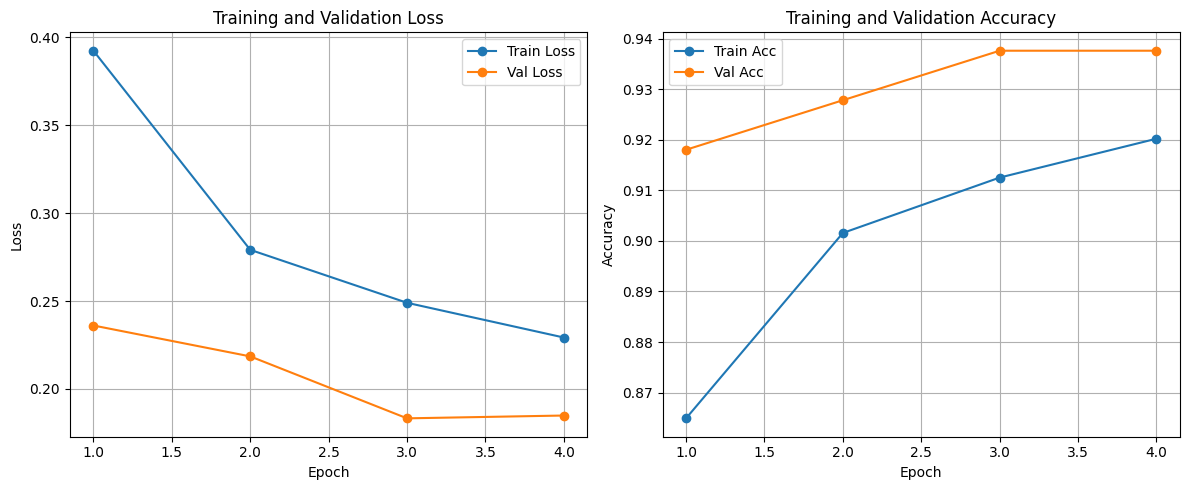

In [ ]:
# 12. training loop and plotting
import matplotlib.pyplot as plt

# show total and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# training loop
num_epochs = 4

train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader_basic, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print("-" * 40)
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

# plotting
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Loss 
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, marker='o', label='Train Loss')
plt.plot(epochs, val_losses, marker='o', label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

# Accuracy 
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, marker='o', label='Train Acc')
plt.plot(epochs, val_accs, marker='o', label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# save the model
model_fe_no_aug_B0 = model
import torch
torch.save(model_fe_no_aug_B0.state_dict(), "B0_fe_no_aug.pth")
print("Model saved as B0_fe_no_aug.pth")

Model saved as B0_fe_no_aug.pth


Sequential(
  (0): Linear(in_features=1280, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=256, out_features=9, bias=True)
)
Total parameters: 4,337,797
Trainable parameters: 330,249
----------------------------------------
Epoch [1/4]
Train Loss: 0.4871 | Train Acc: 0.8322
Val   Loss: 0.3125 | Val   Acc: 0.8965
----------------------------------------
Epoch [2/4]
Train Loss: 0.3786 | Train Acc: 0.8676
Val   Loss: 0.2904 | Val   Acc: 0.8999
----------------------------------------
Epoch [3/4]
Train Loss: 0.3510 | Train Acc: 0.8764
Val   Loss: 0.2758 | Val   Acc: 0.9072
----------------------------------------
Epoch [4/4]
Train Loss: 0.3339 | Train Acc: 0.8821
Val   Loss: 0.2650 | Val   Acc: 0.9102


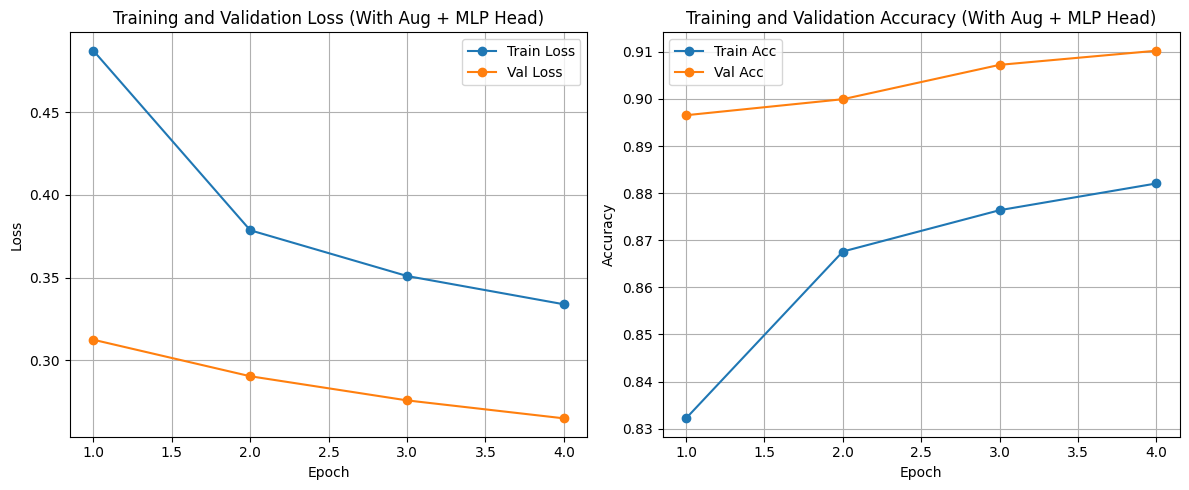

Model saved as B0_fe_aug_mlphead.pth


In [ ]:
# ===== with augmentation: feature extraction + stronger classifier head =====

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import models

# reload pre-trained EfficientNet-B0 and modify the classifier head for augmented training
model_fe_aug_head = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# freeze backbone layers
for param in model_fe_aug_head.parameters():
    param.requires_grad = False

# replace the classifier head with a stronger MLP head
num_features = model_fe_aug_head.classifier[1].in_features
model_fe_aug_head.classifier = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, num_classes)
)
# make sure the new head layers are trainable
for param in model_fe_aug_head.classifier.parameters():
    param.requires_grad = True

model_fe_aug_head = model_fe_aug_head.to(device)


print(model_fe_aug_head.classifier)

# define loss function and optimizer
criterion_aug_head = nn.CrossEntropyLoss()
optimizer_aug_head = torch.optim.Adam(model_fe_aug_head.classifier.parameters(), lr=1e-3)

# show total and trainable parameters for the new model
total_params = sum(p.numel() for p in model_fe_aug_head.parameters())
trainable_params = sum(p.numel() for p in model_fe_aug_head.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

#training loop and plotting for the augmented model
num_epochs = 4

train_losses_aug_head, train_accs_aug_head = [], []
val_losses_aug_head, val_accs_aug_head = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model_fe_aug_head, train_loader_aug, criterion_aug_head, optimizer_aug_head, device
    )
    val_loss, val_acc = evaluate(
        model_fe_aug_head, val_loader, criterion_aug_head, device
    )

    train_losses_aug_head.append(train_loss)
    train_accs_aug_head.append(train_acc)
    val_losses_aug_head.append(val_loss)
    val_accs_aug_head.append(val_acc)

    print("-" * 40)
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

# plotting
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses_aug_head, marker='o', label='Train Loss')
plt.plot(epochs, val_losses_aug_head, marker='o', label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss (With Aug + MLP Head)")
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs_aug_head, marker='o', label='Train Acc')
plt.plot(epochs, val_accs_aug_head, marker='o', label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy (With Aug + MLP Head)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# save
torch.save(model_fe_aug_head.state_dict(), "B0_fe_aug_mlphead.pth")
print("Model saved as B0_fe_aug_mlphead.pth")

In [17]:
import time

Sequential(
  (0): Linear(in_features=1280, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=256, out_features=9, bias=True)
)
Total parameters: 4,337,797
Trainable parameters: 4,337,797
----------------------------------------
Epoch [1/4]
Train Loss: 0.7564 | Train Acc: 0.7978
Val   Loss: 0.1843 | Val   Acc: 0.9444
----------------------------------------
Epoch [2/4]
Train Loss: 0.2004 | Train Acc: 0.9361
Val   Loss: 0.1123 | Val   Acc: 0.9645
----------------------------------------
Epoch [3/4]
Train Loss: 0.1456 | Train Acc: 0.9528
Val   Loss: 0.0802 | Val   Acc: 0.9753
----------------------------------------
Epoch [4/4]
Train Loss: 0.1159 | Train Acc: 0.9623
Val   Loss: 0.0676 | Val   Acc: 0.9799
----------------------------------------
Total training time: 1348.87 seconds
Total training time: 22.48 minutes


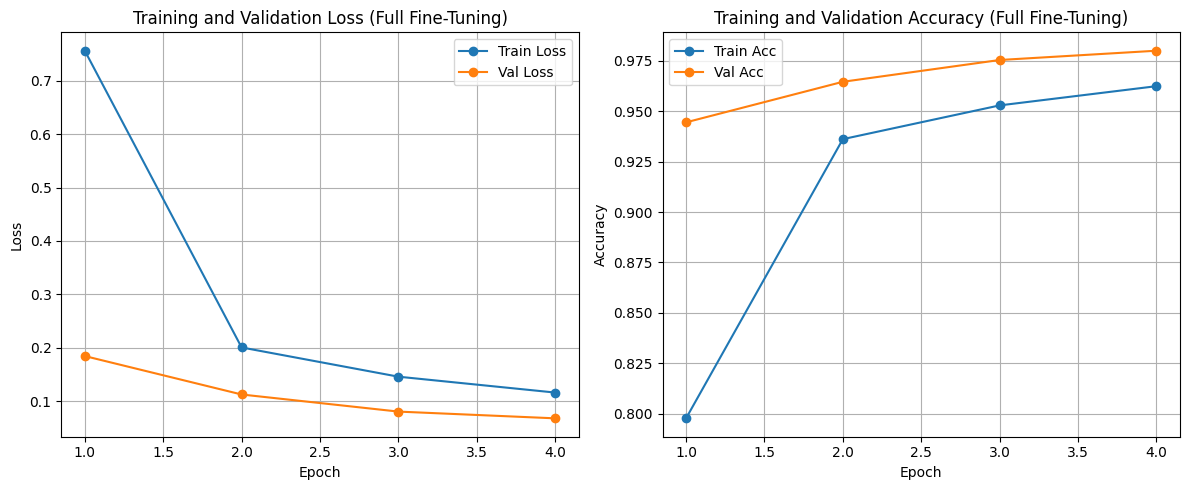

Model saved as B0_full_finetuning.pth


In [ ]:
# full fine-tuning
 

# reload pre-trained EfficientNet-B0, replace the head, and do not freeze any layers
model_full_ft = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# full fine-tuning
for param in model_full_ft.parameters():
    param.requires_grad = True

# replace the classifier head with a stronger MLP head
num_features = model_full_ft.classifier[1].in_features
model_full_ft.classifier = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, num_classes)
)


# make sure the new head layers are trainable
for param in model_full_ft.classifier.parameters():
    param.requires_grad = True

model_full_ft = model_full_ft.to(device)


print(model_full_ft.classifier)

# define loss function and optimizer for full fine-tuning
criterion_full_ft = nn.CrossEntropyLoss()

# full fine-tuning should use a smaller learning rate
optimizer_full_ft = torch.optim.Adam(model_full_ft.parameters(), lr=1e-5)

# show total and trainable parameters for the full fine-tuning model
total_params = sum(p.numel() for p in model_full_ft.parameters())
trainable_params = sum(p.numel() for p in model_full_ft.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# training loop and plotting for full fine-tuning
num_epochs = 4

train_losses_full_ft, train_accs_full_ft = [], []
val_losses_full_ft, val_accs_full_ft = [], []

# training loop for full fine-tuning
start_time = time.time()

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model_full_ft, train_loader_basic, criterion_full_ft, optimizer_full_ft, device
    )
    val_loss, val_acc = evaluate(
        model_full_ft, val_loader, criterion_full_ft, device
    )

    train_losses_full_ft.append(train_loss)
    train_accs_full_ft.append(train_acc)
    val_losses_full_ft.append(val_loss)
    val_accs_full_ft.append(val_acc)

    print("-" * 40)
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

end_time = time.time()
total_time = end_time - start_time
print("-" * 40)
print(f"Total training time: {total_time:.2f} seconds")
print(f"Total training time: {total_time/60:.2f} minutes")

# plotting
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses_full_ft, marker='o', label='Train Loss')
plt.plot(epochs, val_losses_full_ft, marker='o', label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss (Full Fine-Tuning)")
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs_full_ft, marker='o', label='Train Acc')
plt.plot(epochs, val_accs_full_ft, marker='o', label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy (Full Fine-Tuning)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# save
torch.save(model_full_ft.state_dict(), "B0_full_finetuning.pth")
print("Model saved as B0_full_finetuning.pth")